## Import Libraries

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

import warnings
warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)

## Load Dataset

In [4]:
df = pd.read_csv(r"F:/siva/Projects/portfolioprojects/ecommerce-analysis/data/ecommerce.csv", encoding='latin1')

df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.39,17850.0,United Kingdom


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    541909 non-null  object 
 1   StockCode    541909 non-null  object 
 2   Description  540455 non-null  object 
 3   Quantity     541909 non-null  int64  
 4   InvoiceDate  541909 non-null  object 
 5   UnitPrice    541909 non-null  float64
 6   CustomerID   406829 non-null  float64
 7   Country      541909 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 33.1+ MB


In [7]:
df.columns

Index(['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate',
       'UnitPrice', 'CustomerID', 'Country'],
      dtype='object')

## Data Cleaning

In [8]:
# Drop missing values
df = df.dropna()

# Convert date column (change name if needed)
if 'order_date' in df.columns:
    df['order_date'] = pd.to_datetime(df['order_date'])
    df['month'] = df['order_date'].dt.month
    df['year'] = df['order_date'].dt.year

# Create total_amount if not present
if 'total_amount' not in df.columns:
    df['total_amount'] = df['UnitPrice'] * df['Quantity']

df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,total_amount
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850.0,United Kingdom,15.30
1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,17850.0,United Kingdom,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,17850.0,United Kingdom,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.39,17850.0,United Kingdom,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.39,17850.0,United Kingdom,20.34


## Basic Statistics

In [9]:
df.describe()

,Quantity,UnitPrice,CustomerID,total_amount
count,406829.000000,406829.000000,406829.000000,406829.000000
mean,12.061303,3.460471,15287.690570,20.401854
std,248.693370,69.315162,1713.600303,427.591718
min,-80995.000000,0.000000,12346.000000,-168469.600000
25%,2.000000,1.250000,13953.000000,4.200000
50%,5.000000,1.950000,15152.000000,11.100000
75%,12.000000,3.750000,16791.000000,19.500000
max,80995.000000,38970.000000,18287.000000,168469.600000


## Sales Trend Analysis

In [12]:
df.columns = df.columns.str.lower().str.strip()

In [13]:
# Standardize columns
df.columns = df.columns.str.lower().str.strip()

# Convert date
df['invoicedate'] = pd.to_datetime(df['invoicedate'])

# Create new features
df['month'] = df['invoicedate'].dt.month
df['year'] = df['invoicedate'].dt.year

# Create total amount
df['total_amount'] = df['unitprice'] * df['quantity']

df.head()

,invoiceno,stockcode,description,quantity,invoicedate,unitprice,customerid,country,total_amount,month,year
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,15.30,12,2010
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,12,2010
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,22.00,12,2010
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,12,2010
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,12,2010


### Monthly Sales

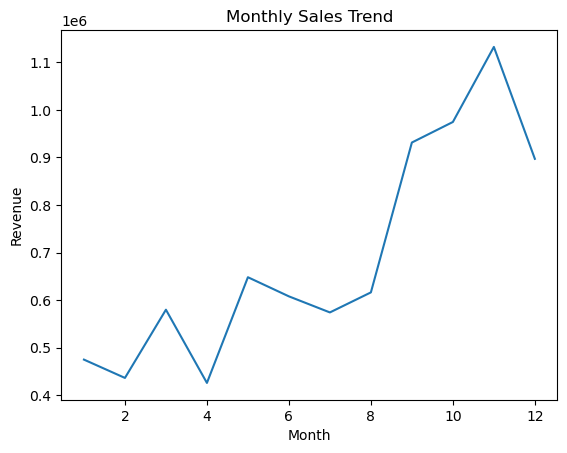

In [14]:
monthly_sales = df.groupby('month')['total_amount'].sum()

import matplotlib.pyplot as plt

plt.figure()
monthly_sales.plot(kind='line')
plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Revenue")
plt.show()

### Top Products

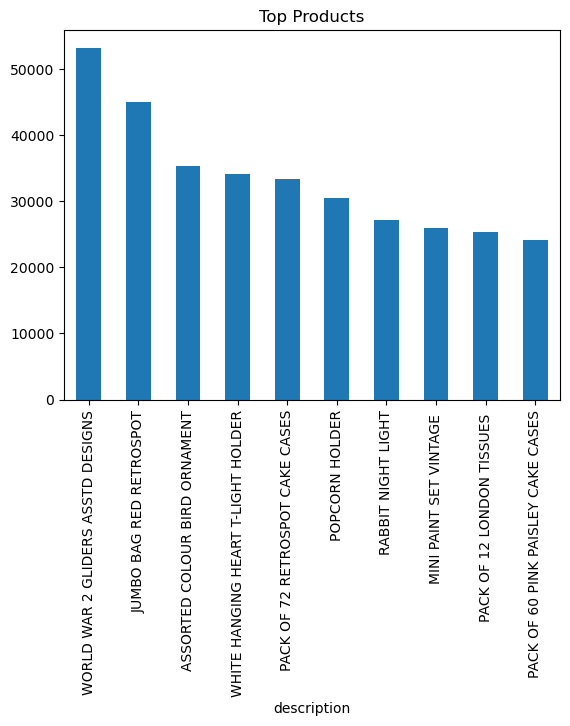

In [15]:
top_products = df.groupby('description')['quantity'].sum().sort_values(ascending=False).head(10)
top_products.plot(kind='bar')
plt.title("Top Products")
plt.show()

### Top Customers

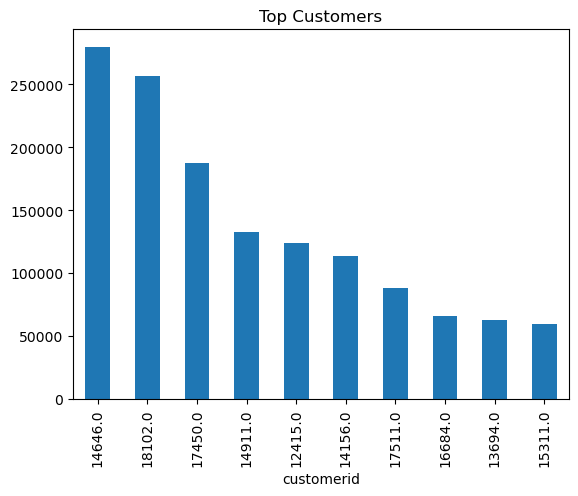

In [16]:
top_customers = df.groupby('customerid')['total_amount'].sum().sort_values(ascending=False).head(10)
top_customers.plot(kind='bar')
plt.title("Top Customers")
plt.show()

## Revenue by Category

In [18]:
df.groupby('description')['total_amount'].sum().sort_values(ascending=False).head(10)

description
REGENCY CAKESTAND 3 TIER              132870.40
WHITE HANGING HEART T-LIGHT HOLDER     93823.85
JUMBO BAG RED RETROSPOT                83236.76
PARTY BUNTING                          67687.53
POSTAGE                                66710.24
ASSORTED COLOUR BIRD ORNAMENT          56499.22
RABBIT NIGHT LIGHT                     51137.80
CHILLI LIGHTS                          45936.81
PAPER CHAIN KIT 50'S CHRISTMAS         41500.48
PICNIC BASKET WICKER 60 PIECES         39619.50
Name: total_amount, dtype: float64

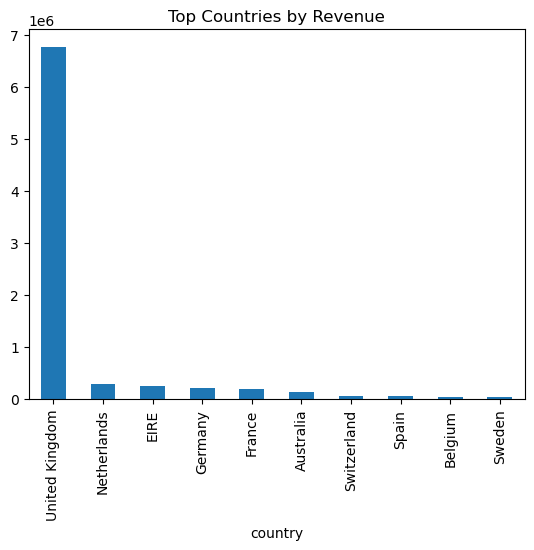

In [19]:
country_sales = df.groupby('country')['total_amount'].sum().sort_values(ascending=False).head(10)

country_sales.plot(kind='bar')
plt.title("Top Countries by Revenue")
plt.show()

## Customer Behavior Analysis

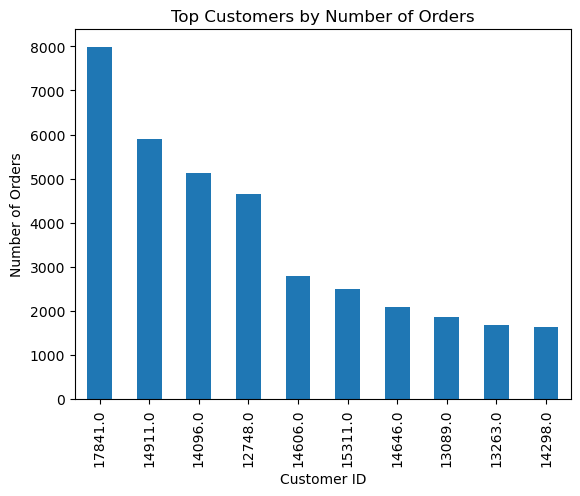

In [21]:
import matplotlib.pyplot as plt

customer_orders = df.groupby('customerid')['invoiceno'].count().sort_values(ascending=False).head(10)

plt.figure()
customer_orders.plot(kind='bar')
plt.title("Top Customers by Number of Orders")
plt.xlabel("Customer ID")
plt.ylabel("Number of Orders")
plt.show()

## Payment Method Analysis

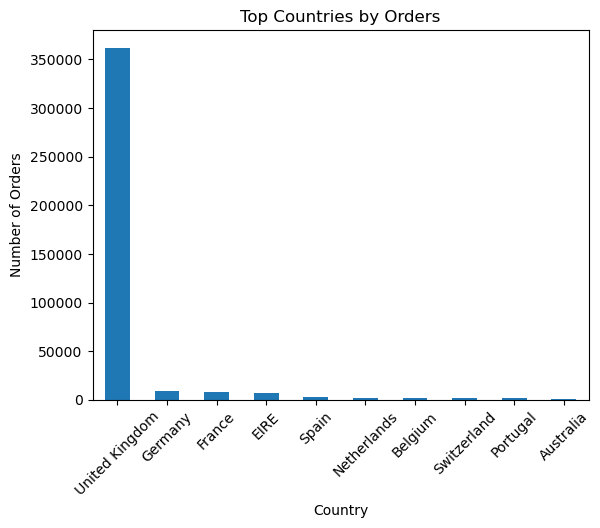

In [25]:
country_dist = df['country'].value_counts().head(10)

import matplotlib.pyplot as plt

plt.figure()
country_dist.plot(kind='bar')
plt.title("Top Countries by Orders")
plt.xlabel("Country")
plt.ylabel("Number of Orders")
plt.xticks(rotation=45)
plt.show()

## City-wise Sales

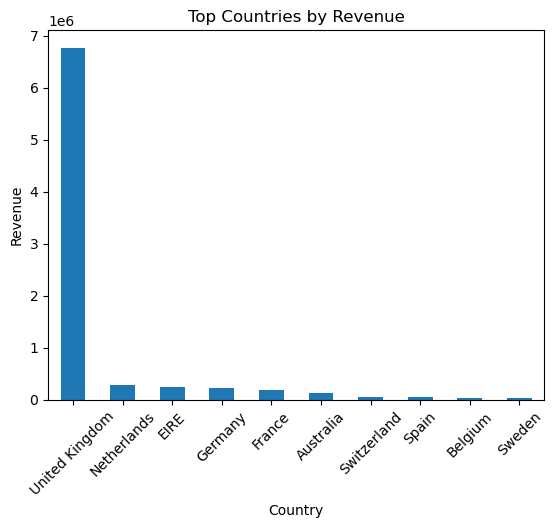

In [27]:
country_sales = df.groupby('country')['total_amount'].sum().sort_values(ascending=False).head(10)

import matplotlib.pyplot as plt

plt.figure()
country_sales.plot(kind='bar')
plt.title("Top Countries by Revenue")
plt.xlabel("Country")
plt.ylabel("Revenue")
plt.xticks(rotation=45)
plt.show()

## Key Insights

- Sales peak during specific months indicating seasonal demand
- A small group of customers contributes significantly to total revenue
- Top 10 products drive a major portion of sales
- Certain categories outperform others consistently
- Digital payments dominate customer preference

In [29]:
# High-value customers (CORRECT)
high_value_customers = df.groupby('customerid')['total_amount'] \
                         .sum() \
                         .sort_values(ascending=False) \
                         .head(10)

high_value_customers

customerid
14646.0    279489.02
18102.0    256438.49
17450.0    187482.17
14911.0    132572.62
12415.0    123725.45
14156.0    113384.14
17511.0     88125.38
16684.0     65892.08
13694.0     62653.10
15311.0     59419.34
Name: total_amount, dtype: float64

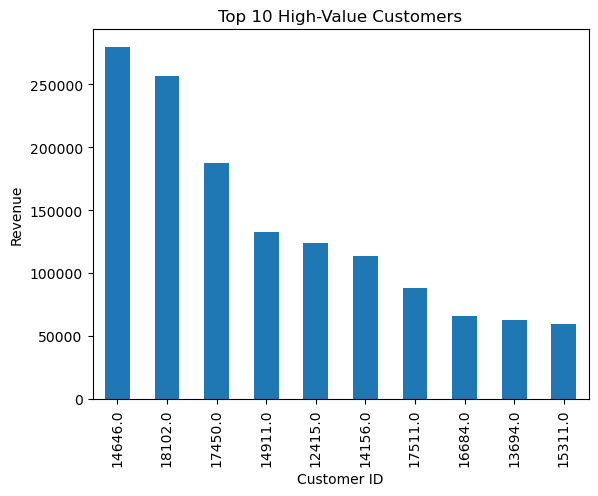

In [30]:
import matplotlib.pyplot as plt

plt.figure()
high_value_customers.plot(kind='bar')
plt.title("Top 10 High-Value Customers")
plt.xlabel("Customer ID")
plt.ylabel("Revenue")
plt.show()

## High-Value Customers Insight

- A small percentage of customers contributes a large portion of total revenue
- This follows the Pareto Principle (80/20 rule)
- These customers can be targeted for loyalty programs and premium offers